In [22]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
print(sns.__version__)

0.13.2


In [23]:
df = pd.read_csv("student_tech_profile.csv")
display(df.head())
display(df.shape)
display(df.size)
display(df.dtypes)

,student_id,branch,year,gender,coding_hours_per_week,problems_solved,github_commits,projects_completed,sleep_hours,attendance_pct,cgpa,internship_done,placed,package_lpa
0,S1000,IT,1,Male,13.8,87,106,3,4.9,69.2,6.69,No,No,NaN
1,S1001,CIVIL,3,Male,11.8,97,141,2,6.4,91.1,6.09,Yes,Yes,6.04
2,S1002,EEE,4,Female,12.1,91,134,2,6.8,81.3,5.33,No,Yes,6.66
3,S1003,ECE,3,Male,2.9,90,111,2,5.9,77.9,6.16,No,No,NaN
4,S1004,CSE,4,Male,14.5,84,103,5,6.3,69.8,7.88,No,Yes,7.31


(1000, 14)

14000

student_id                   str
branch                       str
year                       int64
gender                       str
coding_hours_per_week    float64
problems_solved            int64
github_commits             int64
projects_completed         int64
sleep_hours              float64
attendance_pct           float64
cgpa                     float64
internship_done              str
placed                       str
package_lpa              float64
dtype: object

In [24]:
df.info

<bound method DataFrame.info of     student_id branch  year  gender  coding_hours_per_week  problems_solved  \
0        S1000     IT     1    Male                   13.8               87   
1        S1001  CIVIL     3    Male                   11.8               97   
2        S1002    EEE     4  Female                   12.1               91   
3        S1003    ECE     3    Male                    2.9               90   
4        S1004    CSE     4    Male                   14.5               84   
..         ...    ...   ...     ...                    ...              ...   
995      S1995    CSE     3  Female                   16.3               81   
996      S1996  CIVIL     4    Male                    7.7              112   
997      S1997    CSE     1    Male                   16.2               96   
998      S1998  CIVIL     1    Male                   12.1               91   
999      S1999     IT     2  Female                    8.4               96   

     github_commits

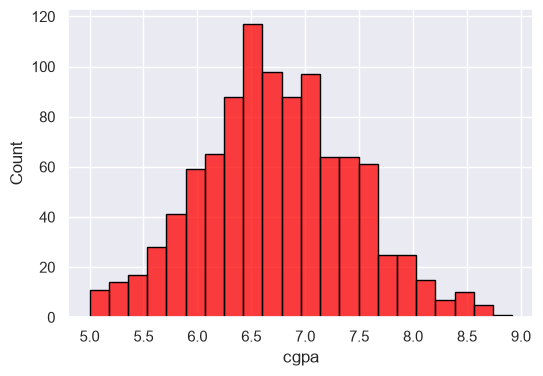

In [25]:
sns.set_theme(style="darkgrid",palette="deep")
sns.set_context("notebook")

fig,ax = plt.subplots(figsize=(6,4))
ax.set_title("")
sns.histplot(data=df,x="cgpa",color="red",edgecolor="black")
plt.show()

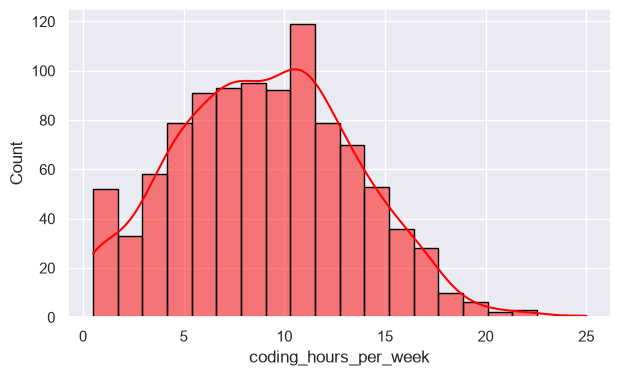

In [26]:
# kde stands for kernel density Estimation that shows curve over histogram
fig,ax=plt.subplots(figsize=(7,4))
sns.histplot(data=df,x="coding_hours_per_week",kde=True,ax=ax,color="red",edgecolor="black")
ax.set_title("")
plt.show()

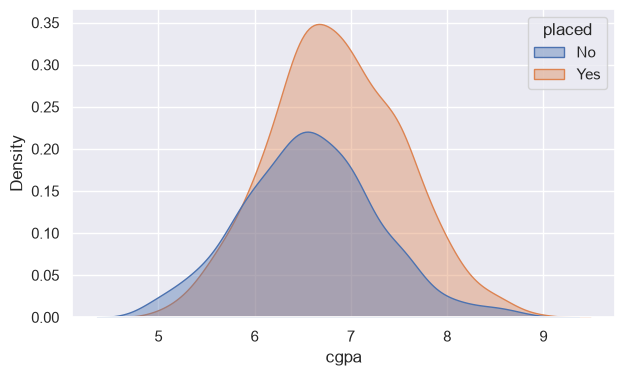

In [27]:

fig,ax= plt.subplots(figsize=(7,4))
sns.kdeplot(data=df,x="cgpa",hue="placed",fill=True,alpha=0.4,ax=ax)
ax.set_title("")
plt.show()

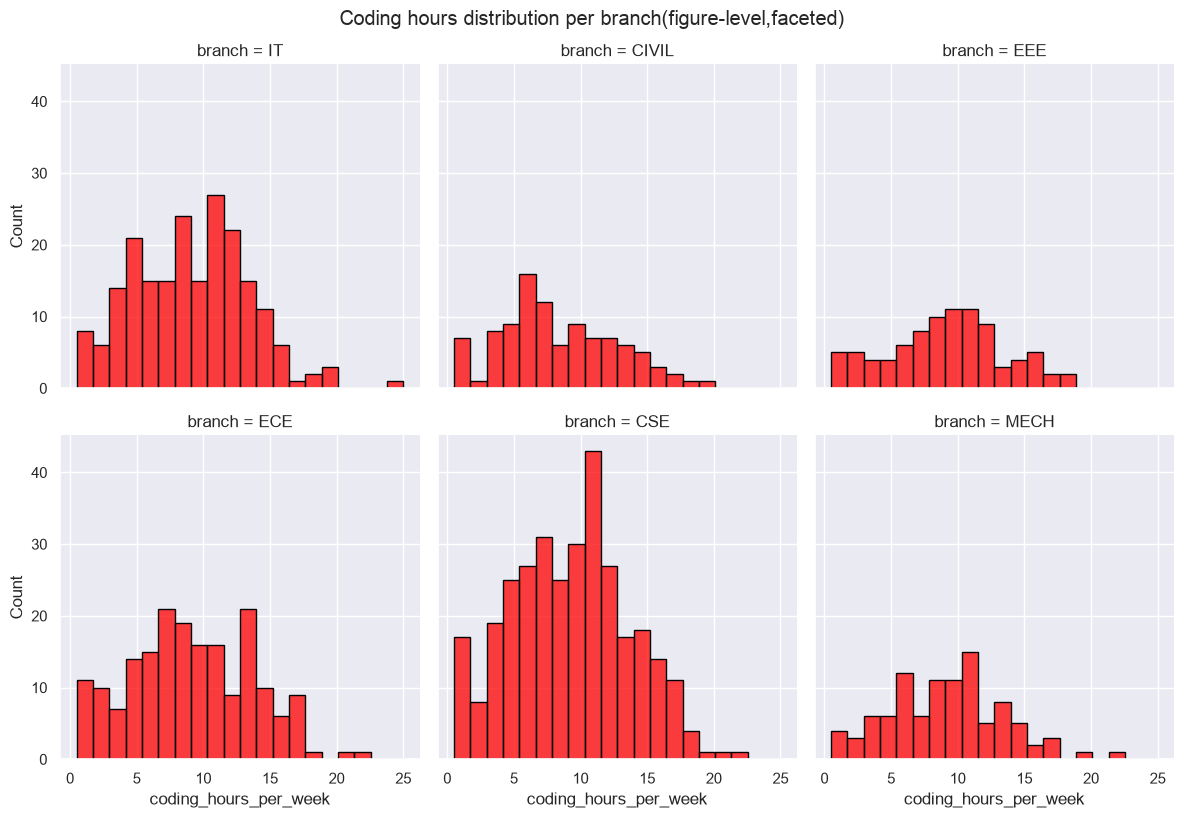

In [28]:
sns.set_theme(style="darkgrid",palette="deep")
sns.displot(data=df,x="coding_hours_per_week",col="branch",col_wrap=3,height=4.0,color="red",edgecolor="black")
plt.suptitle("Coding hours distribution per branch(figure-level,faceted)",y=1.02)
plt.show()

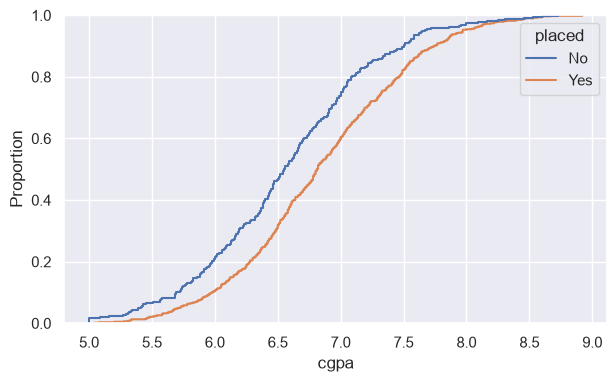

In [29]:
fix,ax = plt.subplots(figsize=(7,4))
sns.ecdfplot(data=df,x="cgpa",hue="placed",ax=ax)
ax.set_title("")
plt.show()

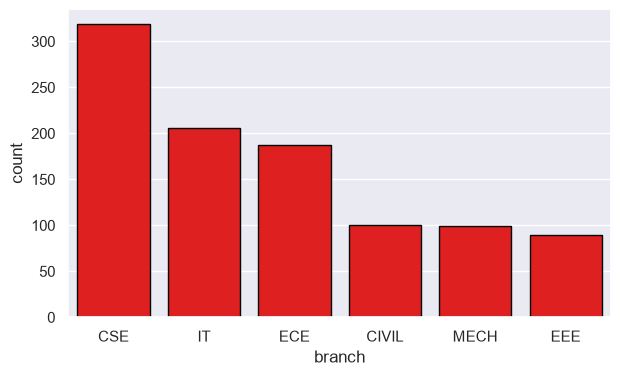

In [30]:
fig,ax=plt.subplots(figsize=(7,4))
sns.set_theme(style="darkgrid",palette="deep")
sns.countplot(data=df,x="branch",order=df['branch'].value_counts().index,ax=ax,color="red",edgecolor="black")
ax.set_title("")
plt.show()

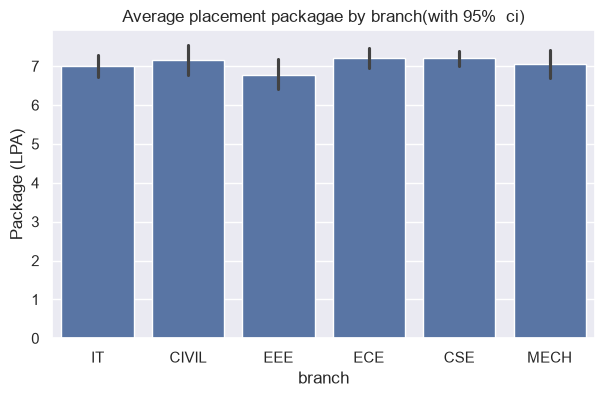

In [31]:
# barplot 
# barplot contains a parameter called errorbar that takes either ci[confidence interval] or standard deviation
# errorbar can also have the value None that represent Nothing/
fig,ax = plt.subplots(figsize=(7,4))
sns.barplot(data=df,ax=ax,errorbar="ci",x="branch",y="package_lpa")
ax.set_title("Average placement packagae by branch(with 95%  ci)")
ax.set_ylabel("Package (LPA)")
plt.show()

# the black bars in the 

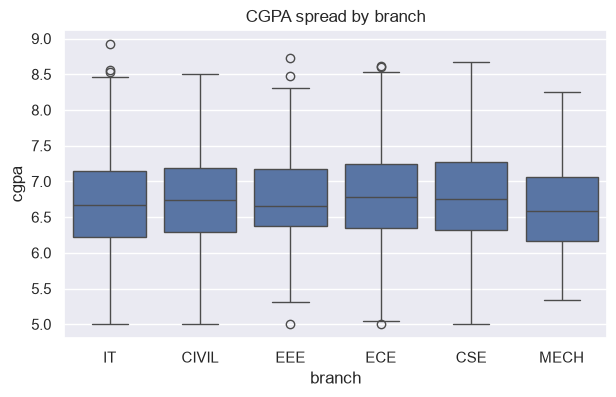

In [32]:
# boxplot 

fig,ax = plt.subplots(figsize=(7,4))
sns.boxplot(data=df,x="branch",y="cgpa",ax=ax)
ax.set_title("CGPA spread by branch")
plt.show()

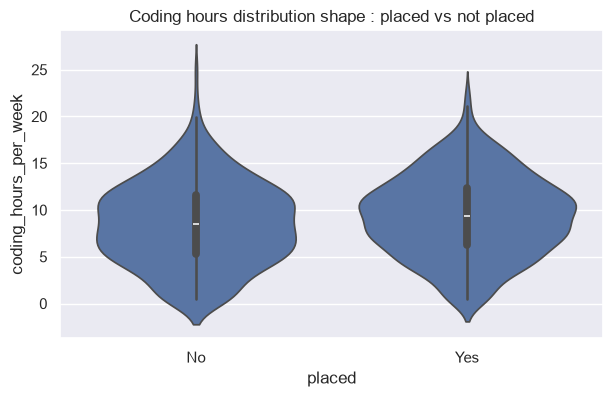

In [33]:
"""
Violine Plot:
 
Wide part
Many students have coding hours around that region.
Narrow part
Few students have coding hours around that region.
"""
fig,ax = plt.subplots(figsize=(7,4))
sns.violinplot(data=df,x="placed",y="coding_hours_per_week",ax=ax)
ax.set_title("Coding hours distribution shape : placed vs not placed")
plt.show()

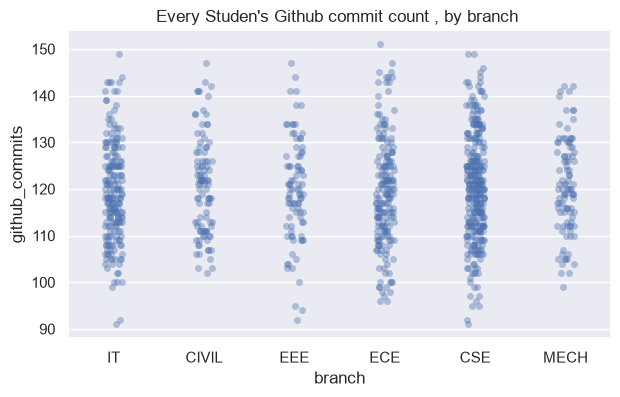

In [34]:
fig,ax=plt.subplots(figsize=(7,4))
sns.stripplot(data=df,x="branch",y="github_commits",alpha=0.4,ax=ax)
ax.set_title("Every Studen's Github commit count , by branch ")
plt.show()

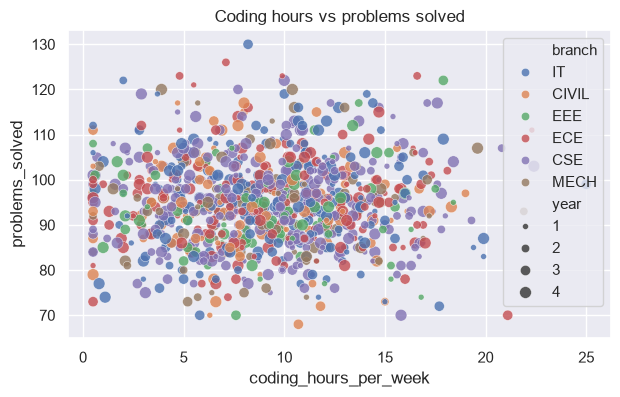

In [35]:
fix,ax = plt.subplots(figsize=(7,4))
sns.scatterplot(data=df,ax=ax,x="coding_hours_per_week",y="problems_solved",size="year",hue="branch",alpha=0.8)
ax.set_title("Coding hours vs problems solved")
plt.show()

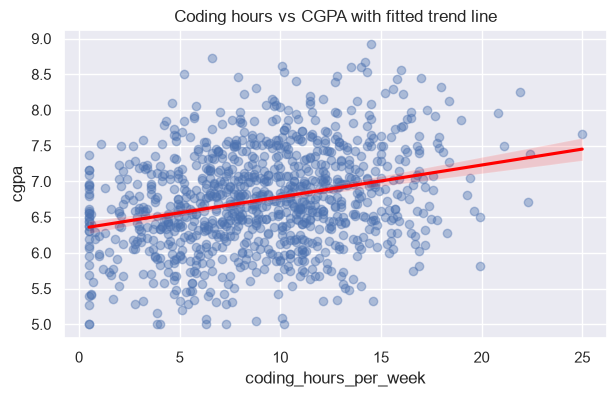

Correlation Value :  0.2805533528901483


In [36]:
""" 
We are using regplot because we want to do two things together:
See the individual students' data using a scatter plot.
See the overall linear trend using a fitted regression line.
"""
""" 
if you plot linear regression between two variables 
and the line is poiting toward up then two variables have positive relation 

and vice versa if the regression line is pointin towards bottom
"""

fig,ax = plt.subplots(figsize=(7,4))
sns.regplot(data=df,x="coding_hours_per_week",y="cgpa",scatter_kws={"alpha":0.4},line_kws={"color":"red"},ax=ax)
ax.set_title("Coding hours vs CGPA with fitted trend line")
plt.show()

corr = df['coding_hours_per_week'].corr(df['cgpa'])
print('Correlation Value : ',corr)

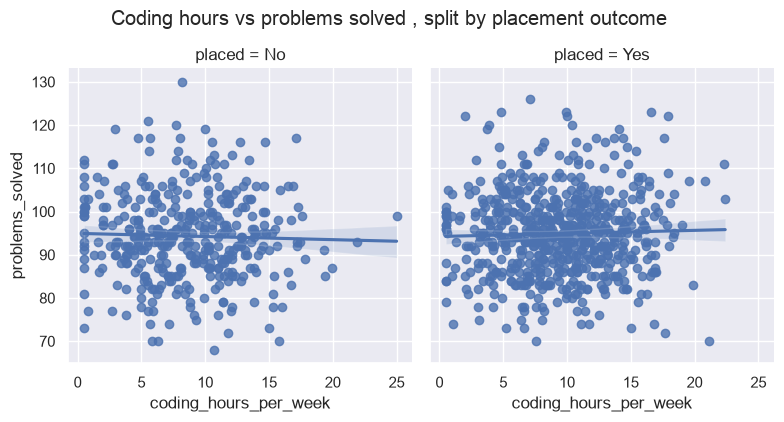

In [37]:
sns.lmplot(data=df,x="coding_hours_per_week",y="problems_solved",col="placed",height=4,aspect=1)
plt.suptitle("Coding hours vs problems solved , split by placement outcome ",y=1.05)
plt.show()

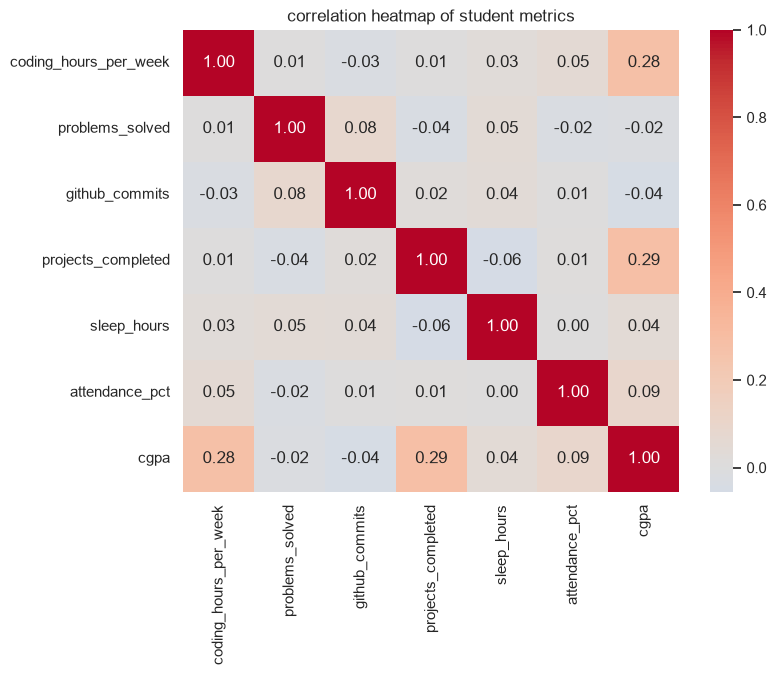

In [ ]:
""" 
annot means annotation.Seaborn writes the actual correlation value inside every cell.
"""
""" 
center=0
Treat zero correlation as the center of the color scale.
"""
""" 
cmp="coolwarm"
The purpose is to visually distinguish:
negative correlations
correlations near zero
positive correlations
 
"""
numeric_cols =['coding_hours_per_week','problems_solved','github_commits','projects_completed','sleep_hours','attendance_pct','cgpa']
corr_matrix = df[numeric_cols].corr()
fig,ax= plt.subplots(figsize=(8,6))
sns.heatmap(corr_matrix,annot=True,fmt=".2f",cmap="coolwarm",center=0,ax=ax)
ax.set_title("correlation heatmap of student metrics")
plt.show()

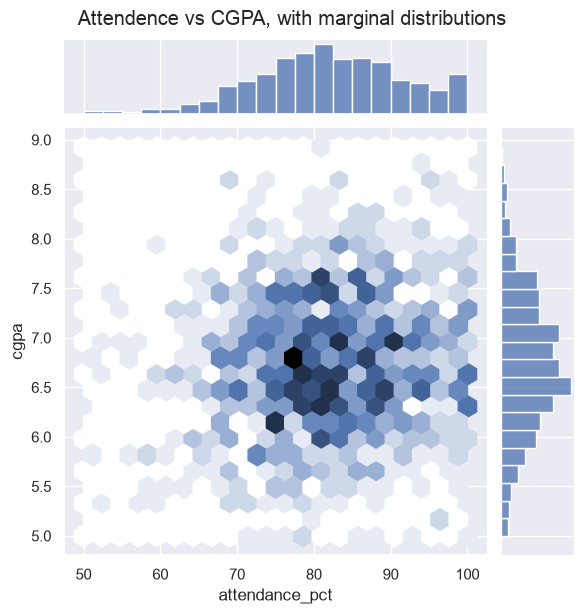

In [42]:
sns.jointplot(data=df,x="attendance_pct",y="cgpa",kind="hex",height=6)
plt.suptitle("Attendence vs CGPA, with marginal distributions",y=1.02)
plt.show()

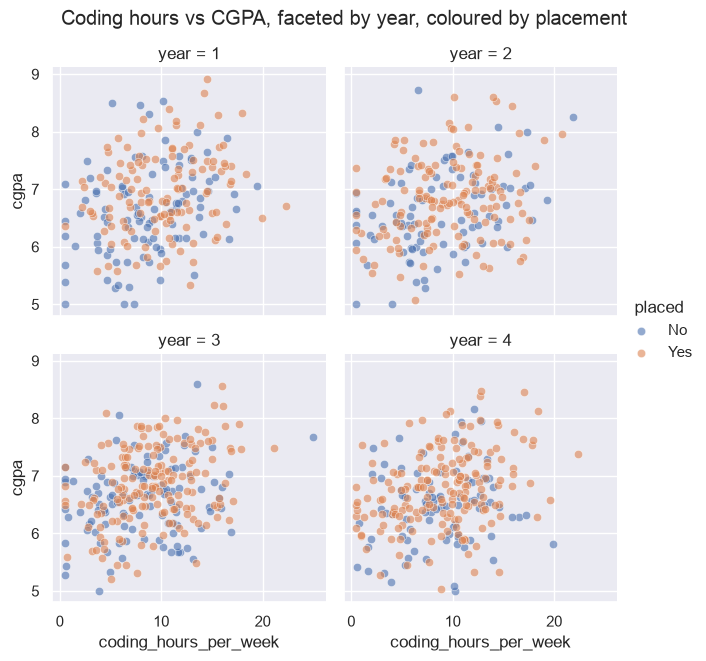

In [43]:
g = sns.FacetGrid(df, col="year", hue="placed", height=3.2, col_wrap=2)
g.map(sns.scatterplot, "coding_hours_per_week", "cgpa", alpha=0.6)
g.add_legend()
g.fig.suptitle("Coding hours vs CGPA, faceted by year, coloured by placement", y=1.03)
plt.show()